In [1]:
pip install tensorflow keras matplotlib

You should consider upgrading via the '/Users/vfosouza/Workspace/genai-health/genai-health-env/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

/Users/vfosouza/Workspace/genai-health/genai-health-env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

/Users/vfosouza/Workspace/genai-health/genai-health-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/vfosouza/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [4]:
datagen = ImageDataGenerator(rescale=1.0/255.0)
train_generator = datagen.flow_from_directory(
    './chest_xray/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5232 images belonging to 2 classes.


In [5]:
from tensorflow.keras import layers, models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid')) #binary classification

/Users/vfosouza/Workspace/genai-health/genai-health-env/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
history = model.fit(train_generator, epochs=10)

/Users/vfosouza/Workspace/genai-health/genai-health-env/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 47s 283ms/step - accuracy: 0.7981 - loss: 0.5778
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 46s 280ms/step - accuracy: 0.9670 - loss: 0.0924
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 48s 289ms/step - accuracy: 0.9831 - loss: 0.0549
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 48s 290ms/step - accuracy: 0.9859 - loss: 0.0426
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 48s 293ms/step - accuracy: 0.9924 - loss: 0.0265
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 46s 281ms/step - accuracy: 0.9900 - loss: 0.0286
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 47s 285ms/step - accuracy: 0.9914 - loss: 0.0189
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 32s 192ms/step - accuracy: 0.9988 - loss: 0.0039
Epoch 9/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 31s 187ms/step - accuracy: 1.0000 - loss: 0.0011
Epoch 10/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 31s 188ms/step - accuracy: 0.9975 - loss: 0.0104


In [9]:
validation_generator = datagen.flow_from_directory(
    './chest_xray/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)
model.evaluate(validation_generator)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8199 - loss: 1.4397


[1.5575475692749023, 0.8092948794364929]

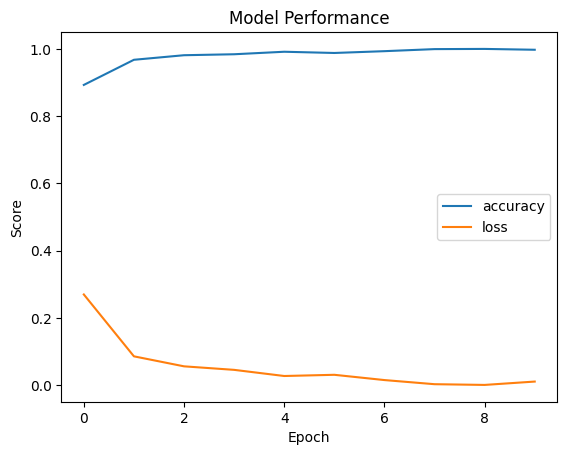

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['loss'], label='loss')
plt.title('Model Performance')
plt.ylabel('Score')
plt.xlabel('Epoch')
plt.legend()
plt.show()